# ACM : Análisis de Correspondencia Múltiple  


# 1. Introducción

## ¿Qué es el Análisis de Correspondencia Múltiple (ACM)?

El **Análisis de Correspondencia Múltiple (ACM)** es una técnica estadística multivariada de **reducción de dimensionalidad** diseñada para analizar de forma conjunta **múltiples variables categóricas**. Puede entenderse como una extensión del Análisis de Correspondencias Simple y como una alternativa al PCA cuando la información no es numérica continua, sino cualitativa.

El ACM transforma las categorías de varias variables en un **espacio factorial de baja dimensión**, en el cual:

- las categorías que tienden a aparecer juntas en los individuos se ubican **cerca** entre sí,
- las categorías poco asociadas o contrastantes aparecen **alejadas**,
- y los individuos con perfiles similares pueden agruparse en regiones próximas del plano.

Esto permite sintetizar estructuras complejas de asociación y facilitar la interpretación de patrones presentes en la población analizada.

---

## ¿Qué problema resuelve en este estudio?

La base de datos del **Sisbén IV** contiene múltiples variables categóricas relacionadas con las condiciones de vida de las personas. En particular, este estudio se concentra en variables asociadas con:

- **educación** (`per015`, `per016`, `per017`),
- **actividad e inserción laboral** (`per018`, `per019`, `per020`),
- y **contexto territorial** (`zona`).

Estas variables no pueden analizarse adecuadamente con técnicas tradicionales como el **Análisis de Componentes Principales (PCA)**, ya que no poseen una estructura métrica continua. El ACM resuelve este problema al representar las categorías en un espacio numérico interpretable, preservando sus relaciones de asociación.

En este contexto, el ACM permite:

| Desafío | Aporte del ACM |
|--------|----------------|
| Variables cualitativas | Representa sus categorías en un espacio geométrico interpretable |
| Múltiples variables sociales interrelacionadas | Resume la información en pocas dimensiones |
| Dificultad para detectar perfiles sociales | Permite identificar agrupamientos y asociaciones entre categorías |
| Relación entre educación y empleo | Facilita construir tipologías educativo-laborales |
| Diferencias territoriales | Permite interpretar el papel de la zona como factor ilustrativo |

Así, el ACM constituye una herramienta adecuada para explorar la estructura de los **perfiles educativo-laborales** de la población y su relación con condiciones socioeconómicas observables en el Sisbén IV.

---

## Objetivo general

Identificar perfiles educativo-laborales de la población registrada en el Sisbén IV mediante Análisis de Correspondencia Múltiple, a partir de variables categóricas de educación, actividad laboral y posición ocupacional.

---

## Objetivos específicos

1. Analizar las asociaciones entre **nivel educativo**, **participación en estudio**, **actividad principal**, **posición ocupacional** y **cotización a pensión**.
2. Identificar **perfiles de inserción laboral** asociados con diferentes trayectorias educativas.
3. Describir la distribución de dichos perfiles según variables ilustrativas como **zona**, **sexo**, **edad** y **clasificación Sisbén**.
4. Explorar si los perfiles identificados se relacionan con condiciones de mayor vulnerabilidad social, como la **pobreza multidimensional proxy**.

---

## Preguntas guía

1. **¿Qué asociaciones existen entre las variables educativas y laborales de la población Sisbén IV?**
2. **¿Qué perfiles educativo-laborales pueden identificarse a partir del ACM?**
3. **¿Qué categorías aparecen más próximas entre sí en el espacio factorial y qué tipo de población representan?**
4. **¿Cómo se distribuyen los perfiles identificados según zona urbano-rural, sexo y grupos de edad?**
5. **¿Existe relación entre ciertos perfiles educativo-laborales y condiciones de vulnerabilidad social?**

## Contexto de los Datos:

### Dicionario de Variables
El **Departamento Nacional de Planeación (DNP)** publica muestras anonimizadas del Sisbén IV con información de personas, viviendas y hogares a nivel nacional.

| Variable        | Nombre                                                                         | Tipo estadístico | Formato   | Ancho | Decimales | Rango / valores          | Descripción completa                                                                                                                                                                                                                                                                                                                                                                                                                                                            | Tipo lógico                   |
| --------------- | ------------------------------------------------------------------------------ | ---------------: | --------- | ----: | --------: | ------------------------ | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | ----------------------------- |
| `cod_mpio`      | Código municipio                                                               |         Continua | numeric   |     5 |         0 | 5001–99773               | Código del municipio.                                                                                                                                                                                                                                                                                                                                                                                                                                                           | Identificadora                |
| `llave`         | Consecutivo de vivienda                                                        |         Continua | numeric   |     4 |         0 | 1–3401                   | Identificador consecutivo de la vivienda.                                                                                                                                                                                                                                                                                                                                                                                                                                       | Identificadora                |
| `hogar`         | Consecutivo de hogar                                                           |         Discreta | numeric   |     2 |         0 | 1–15                     | Identificador consecutivo del hogar dentro de la vivienda.                                                                                                                                                                                                                                                                                                                                                                                                                      | Identificadora                |
| `orden`         | Consecutivo de personas                                                        |         Discreta | numeric   |     2 |         0 | 1–21                     | Identificador consecutivo de la persona dentro del hogar.                                                                                                                                                                                                                                                                                                                                                                                                                       | Identificadora                |
| `zona`          | Zona                                                                           |         Discreta | numeric   |     1 |         0 | 1–2                      | 1 = Cabecera; 2 = Centro Poblado, Rural Disperso.                                                                                                                                                                                                                                                                                                                                                                                                                               | Categórica                    |
| `fex`           | Factor de expansión                                                            |         Continua | numeric   |    12 |         0 | 1.037037037–1842.6678201 | Factor de expansión de la observación.                                                                                                                                                                                                                                                                                                                                                                                                                                          | Continua                      |
| `corte`         | Corte                                                                          |         Discreta | character |     8 |         — | Texto                    | Corte de la base de datos.                                                                                                                                                                                                                                                                                                                                                                                                                                                      | Categórica                    |
| `grupo`         | Grupo Sisbén IV                                                                |         Discreta | character |     2 |         — | Texto                    | Grupo de clasificación del Sisbén IV.                                                                                                                                                                                                                                                                                                                                                                                                                                           | Categórica                    |
| `nivel`         | Nivel Sisbén IV                                                                |         Discreta | numeric   |     2 |         0 | 1–21                     | Nivel dentro del grupo Sisbén IV.                                                                                                                                                                                                                                                                                                                                                                                                                                               | Ordinal                       |
| `clasificacion` | Clasificación                                                                  |         Discreta | character |     4 |         — | Texto                    | Clasificación de la persona dentro del esquema Sisbén IV.                                                                                                                                                                                                                                                                                                                                                                                                                       | Categórica                    |
| `per001`        | Sexo                                                                           |         Discreta | numeric   |     1 |         0 | 1–2                      | 1 = Hombre; 2 = Mujer.                                                                                                                                                                                                                                                                                                                                                                                                                                                          | Binaria                       |
| `per002`        | Edad                                                                           |         Discreta | numeric   |     1 |         0 | 1–6                      | 1 = 0 a 5 años; 2 = 6 a 11 años; 3 = 12 a 17 años; 4 = 18 a 28 años; 5 = 29 a 59 años; 6 = 60 años y más.                                                                                                                                                                                                                                                                                                                                                                       | Ordinal                       |
| `per003`        | Cuál es el parentesco con el jefe del hogar                                    |         Discreta | numeric   |     2 |         0 | 1–19                     | 1 = Jefe; 2 = Conyuge o compañera (o); 3 = Hijos; 4 = Nietos; 5 = Padres; 6 = Hermanos; 7 = Yerno o nuera; 8 = Abuelos; 9 = Suegros; 10 = Tios; 11 = Sobrinos; 12 = Primos; 13 = Cuñados; 14 = Otros parientes; 15 = Empleado(a) de servicio doméstico; 16 = Pariente del servicio doméstico; 17 = Pensionista; 18 = Pariente de pensionista; 19 = No pariente.                                                                                                                 | Categórica                    |
| `per004`        | Estado civil                                                                   |         Discreta | numeric   |     1 |         0 | 1–2                      | 1 = Union libre, Casado; 2 = Viudo, Separado o divorciado, Soltero.                                                                                                                                                                                                                                                                                                                                                                                                             | Binaria                       |
| `per005`        | ¿El Cónyuge vive en el hogar?                                                  |         Discreta | numeric   |     1 |         0 | 1–9                      | 1 = Si; 2 = No; 9 = No aplica por flujo.                                                                                                                                                                                                                                                                                                                                                                                                                                        | Binaria (Sí/No con No aplica) |
| `per005b`       | Numero de orden del cónyuge                                                    |         Discreta | numeric   |     2 |         0 | 1–99                     | Número de orden de la persona identificada como cónyuge dentro del hogar; 99 = No aplica por flujo.                                                                                                                                                                                                                                                                                                                                                                             | Identificadora                |
| `per006`        | ¿El padre o la madre vive en el hogar?                                         |         Discreta | numeric   |     1 |         0 | 1–2                      | 1 = Si; 2 = No.                                                                                                                                                                                                                                                                                                                                                                                                                                                                 | Binaria (Sí/No)               |
| `per006b`       | Numero de orden del padre o madre                                              |         Discreta | numeric   |     2 |         0 | 1–99                     | Número de orden del padre o madre dentro del hogar; 99 = No aplica por flujo.                                                                                                                                                                                                                                                                                                                                                                                                   | Identificadora                |
| `per007`        | Seguridad social                                                               |         Discreta | numeric   |     1 |         0 | 0–9                      | 0 = Ninguna; 1 = Contributivo; 2 = Especial (Fuerzas Armadas, Ecopetrol, universidades públicas, magisterio); 3 = Subsidiado (EPS-S); 9 = No sabe.                                                                                                                                                                                                                                                                                                                              | Categórica                    |
| `per008`        | En los últimos 30 días, sufrió alguna enfermedad                               |         Discreta | numeric   |     1 |         0 | 1–2                      | 1 = Si; 2 = No.                                                                                                                                                                                                                                                                                                                                                                                                                                                                 | Binaria (Sí/No)               |
| `per009`        | Acudió a una institución prestadora de servicios de salud                      |         Discreta | numeric   |     1 |         0 | 1–9                      | 1 = Si; 2 = No; 9 = No aplica por flujo.                                                                                                                                                                                                                                                                                                                                                                                                                                        | Binaria (Sí/No con No aplica) |
| `per010`        | Lo atendieron                                                                  |         Discreta | numeric   |     1 |         0 | 1–9                      | 1 = Si; 2 = No; 9 = No aplica por flujo.                                                                                                                                                                                                                                                                                                                                                                                                                                        | Binaria (Sí/No con No aplica) |
| `per011`        | Está embarazada                                                                |         Discreta | numeric   |     1 |         0 | 1–9                      | 1 = Si; 2 = No; 9 = No aplica por flujo.                                                                                                                                                                                                                                                                                                                                                                                                                                        | Binaria (Sí/No con No aplica) |
| `per012`        | Ha tenido hijos                                                                |         Discreta | numeric   |     1 |         0 | 1–9                      | 1 = Si; 2 = No; 9 = No aplica por flujo.                                                                                                                                                                                                                                                                                                                                                                                                                                        | Binaria (Sí/No con No aplica) |
| `per013`        | Donde o con quien permanece, durante la mayor parte del tiempo                 |         Discreta | numeric   |     1 |         0 | 1–9                      | 1 = Asiste a un lugar comunitario, jardín o centro de desarrollo infantil o colegio; 2 = Con su padre o madre en la casa; 3 = Con su padre o madre en el trabajo; 4 = Con empleada o niñera en la casa; 5 = Al cuidado de un pariente de 18 años o más; 6 = Al cuidado de un pariente menor de 18 años; 7 = En casa solo; 8 = Otro; 9 = No aplica por flujo.                                                                                                                    | Categórica                    |
| `per014`        | Recibe o toma desayuno o almuerzo donde permanece la mayor parte del tiempo    |         Discreta | numeric   |     1 |         0 | 1–9                      | 1 = Si; 2 = No; 9 = No aplica por flujo.                                                                                                                                                                                                                                                                                                                                                                                                                                        | Binaria (Sí/No con No aplica) |
| `per015`        | Sabe leer y escribir                                                           |         Discreta | numeric   |     1 |         0 | 1–9                      | 1 = Si; 2 = No; 9 = No aplica por flujo.                                                                                                                                                                                                                                                                                                                                                                                                                                        | Binaria (Sí/No con No aplica) |
| `per016`        | Actualmente estudia (asiste al preescolar, escuela, colegio o universidad)     |         Discreta | numeric   |     1 |         0 | 1–9                      | 1 = Si; 2 = No; 9 = No aplica por flujo.                                                                                                                                                                                                                                                                                                                                                                                                                                        | Binaria (Sí/No con No aplica) |
| `per017`        | Nivel educativo                                                                |         Discreta | numeric   |     1 |         0 | 1–9                      | 1 = Ninguno, Preescolar; 2 = Básica primaria (1o. - 5o), Básica secundaria (6o. - 9o.), Media (10o. 13o.); 3 = Técnico o tecnológico, Universitario, Postgrado; 9 = No aplica por flujo.                                                                                                                                                                                                                                                                                        | Ordinal                       |
| `per018`        | Está cotizando a un fondo de pensiones                                         |         Discreta | numeric   |     1 |         0 | 1–9                      | 1 = Si; 2 = No; 3 = Pensionado; 9 = No aplica por flujo.                                                                                                                                                                                                                                                                                                                                                                                                                        | Categórica                    |
| `per019`        | Cuál fue su actividad principal en el último mes                               |         Discreta | numeric   |     1 |         0 | 1–9                      | 1 = Sin actividad; 2 = Trabajando; 3 = Buscando trabajo; 4 = Estudiando; 5 = Oficios del Hogar, Rentista, Jubilado o pensionado, Incapacitado permanentemente; 9 = No aplica por flujo.                                                                                                                                                                                                                                                                                         | Categórica                    |
| `per020`        | Posición ocupacional                                                           |         Discreta | numeric   |     2 |         0 | 1–99                     | 1 = Empleado de empresa particular; 2 = Empleado del gobierno; 3 = Empleado domestico; 4 = Profesional independiente; 5 = Trabajador independiente o por cuenta propia; 6 = Patrón o empleador; 7 = Trabajador de finca, tierra o parcela propia, en arriendo, aparcería o usufructo; 8 = Trabajador sin remuneración; 9 = Ayudante sin remuneración (hijo o familiar de: empleados domésticos, mayordomos, jornaleros, etc.); 10 = Jornalero o peón; 99 = No aplica por flujo. | Categórica                    |
| `h_5`           | Proxy: Indicador de pobreza multidimensional                                   |         Discreta | numeric   |     1 |         0 | 0–1                      | 0 = No; 1 = Si.                                                                                                                                                                                                                                                                                                                                                                                                                                                                 | Binaria (Verdadero/Falso)     |
| `i1`            | Privación IPM Proxy - Bajo logro educativo                                     |         Discreta | numeric   |     1 |         0 | 0–1                      | 0 = No; 1 = Si.                                                                                                                                                                                                                                                                                                                                                                                                                                                                 | Binaria (Verdadero/Falso)     |
| `i2`            | Privación IPM Proxy - Analfabetismo                                            |         Discreta | numeric   |     1 |         0 | 0–1                      | 0 = No; 1 = Si.                                                                                                                                                                                                                                                                                                                                                                                                                                                                 | Binaria (Verdadero/Falso)     |
| `i3`            | Privación IPM Proxy - Inasistencia escolar                                     |         Discreta | numeric   |     1 |         0 | 0–1                      | 0 = No; 1 = Si.                                                                                                                                                                                                                                                                                                                                                                                                                                                                 | Binaria (Verdadero/Falso)     |
| `i4`            | Privación IPM Proxy - Rezago escolar                                           |         Discreta | numeric   |     1 |         0 | 0–1                      | 0 = No; 1 = Si.                                                                                                                                                                                                                                                                                                                                                                                                                                                                 | Binaria (Verdadero/Falso)     |
| `i5`            | Privación IPM Proxy - Barreras a servicios para cuidado de la primera infancia |         Discreta | numeric   |     1 |         0 | 0–1                      | 0 = No; 1 = Si.                                                                                                                                                                                                                                                                                                                                                                                                                                                                 | Binaria (Verdadero/Falso)     |
| `i6`            | Privación IPM Proxy - Trabajo infantil                                         |         Discreta | numeric   |     1 |         0 | 0–1                      | 0 = No; 1 = Si.                                                                                                                                                                                                                                                                                                                                                                                                                                                                 | Binaria (Verdadero/Falso)     |
| `i7`            | Privación IPM Proxy - Desempleo de larga duración                              |         Discreta | numeric   |     1 |         0 | 0–1                      | 0 = No; 1 = Si.                                                                                                                                                                                                                                                                                                                                                                                                                                                                 | Binaria (Verdadero/Falso)     |
| `i8`            | Privación IPM Proxy - Trabajo informal                                         |         Discreta | numeric   |     1 |         0 | 0–1                      | 0 = No; 1 = Si.                                                                                                                                                                                                                                                                                                                                                                                                                                                                 | Binaria (Verdadero/Falso)     |
| `i9`            | Privación IPM Proxy - Sin aseguramiento en salud                               |         Discreta | numeric   |     1 |         0 | 0–1                      | 0 = No; 1 = Si.                                                                                                                                                                                                                                                                                                                                                                                                                                                                 | Binaria (Verdadero/Falso)     |
| `i10`           | Privación IPM Proxy - Barreras de acceso a servicios de salud                  |         Discreta | numeric   |     1 |         0 | 0–1                      | 0 = No; 1 = Si.                                                                                                                                                                                                                                                                                                                                                                                                                                                                 | Binaria (Verdadero/Falso)     |
| `i11`           | Privación IPM Proxy - Sin acceso a fuentes de agua mejorada                    |         Discreta | numeric   |     1 |         0 | 0–1                      | 0 = No; 1 = Si.                                                                                                                                                                                                                                                                                                                                                                                                                                                                 | Binaria (Verdadero/Falso)     |
| `i12`           | Privación IPM Proxy - Inadecuada eliminación de excretas                       |         Discreta | numeric   |     1 |         0 | 0–1                      | 0 = No; 1 = Si.                                                                                                                                                                                                                                                                                                                                                                                                                                                                 | Binaria (Verdadero/Falso)     |
| `i13`           | Privación IPM Proxy - Material inadecuado de pisos                             |         Discreta | numeric   |     1 |         0 | 0–1                      | 0 = No; 1 = Si.                                                                                                                                                                                                                                                                                                                                                                                                                                                                 | Binaria (Verdadero/Falso)     |
| `i14`           | Privación IPM Proxy - Material inadecuado de paredes exteriores                |         Discreta | numeric   |     1 |         0 | 0–1                      | 0 = No; 1 = Si.                                                                                                                                                                                                                                                                                                                                                                                                                                                                 | Binaria (Verdadero/Falso)     |
| `i15`           | Privación IPM Proxy - Hacinamiento crítico                                     |         Discreta | numeric   |     1 |         0 | 0–1                      | 0 = No; 1 = Si.                                                                                                                                                                                                                                                                                                                                                                                                                                                                 | Binaria (Verdadero/Falso)     |


## 1. Variables identificadoras (no utilizadas en el ACM)

Estas variables permiten identificar de manera única cada observación dentro de la base, pero **no contienen información sustantiva sobre las condiciones socioeconómicas del individuo**, por lo que no deben incluirse en el análisis factorial.

| Variable | Descripción |
|----------|-------------|
| `cod_mpio` | Código del municipio |
| `llave` | Identificador de vivienda |
| `hogar` | Identificador del hogar |
| `orden` | Identificador del individuo |
| `per005b` | Orden del cónyuge |
| `per006b` | Orden del padre o madre |

Estas variables son útiles para organización y trazabilidad de datos, pero no aportan información analítica relevante para el ACM.

---

## 2. Variables demográficas y de contexto

Estas variables describen características básicas de los individuos y su entorno. Aunque son importantes, se utilizan principalmente como **variables ilustrativas**, ya que su función es interpretar los resultados y no construir las dimensiones.

| Variable | Descripción |
|----------|-------------|
| `per001` | Sexo |
| `per002` | Grupo de edad |
| `per003` | Parentesco con el jefe del hogar |
| `per004` | Estado civil |
| `zona` | Zona urbana/rural |
| `grupo` | Grupo Sisbén |
| `nivel` | Nivel Sisbén |
| `clasificacion` | Clasificación Sisbén |

Estas variables permiten contextualizar los perfiles encontrados, por ejemplo, identificando diferencias por edad, género o territorio.

---

## 3. Variables educativas

Estas variables representan el capital educativo de los individuos y su relación con el sistema educativo.

| Variable | Descripción |
|----------|-------------|
| `per015` | Sabe leer y escribir |
| `per016` | Actualmente estudia |
| `per017` | Nivel educativo alcanzado |

Estas variables son fundamentales para analizar trayectorias educativas y su relación con la inserción laboral.

---

## 4. Variables laborales

Estas variables describen la participación del individuo en el mercado laboral.

| Variable | Descripción |
|----------|-------------|
| `per018` | Cotiza a pensión |
| `per019` | Actividad principal |
| `per020` | Posición ocupacional |

Estas permiten distinguir entre empleo, desempleo, informalidad y otras formas de ocupación.

---

## 5. Variables de privación (IPM Proxy)

Estas variables capturan condiciones de vulnerabilidad asociadas a distintas dimensiones del bienestar.

### Educación
- `i1`: Bajo logro educativo  
- `i2`: Analfabetismo  
- `i3`: Inasistencia escolar  
- `i4`: Rezago escolar  

### Trabajo
- `i6`: Trabajo infantil  
- `i7`: Desempleo de larga duración  
- `i8`: Trabajo informal  

### Salud
- `i9`: Sin aseguramiento  
- `i10`: Barreras de acceso  

### Vivienda y servicios
- `i11`: Sin acceso a agua mejorada  
- `i12`: Inadecuada eliminación de excretas  
- `i13`: Pisos inadecuados  
- `i14`: Paredes inadecuadas  
- `i15`: Hacinamiento  

Estas variables permiten aproximar la **pobreza multidimensional** y son clave para interpretar desigualdades estructurales.

---

## 6. Variables seleccionadas para el ACM

A partir del universo de variables disponibles, se seleccionó un subconjunto que permite analizar de manera coherente los **perfiles educativo-laborales**.

### Variables activas (estructurales)

| Variable | Justificación |
|----------|--------------|
| `per015` | Captura alfabetización |
| `per016` | Mide participación educativa |
| `per017` | Resume nivel educativo |
| `i1` | Refuerza bajo capital educativo |
| `i4` | Captura rezago escolar |
| `per019` | Define estado laboral |
| `per020` | Caracteriza tipo de ocupación |
| `i7` | Identifica desempleo estructural |
| `i8` | Representa informalidad |

Estas variables construyen las dimensiones principales del análisis.

---

### Variables ilustrativas (interpretativas)

| Variable | Justificación |
|----------|--------------|
| `per001` | Permite analizar diferencias de género |
| `per018` | Aproxima formalidad laboral |
| `zona` | Permite observar desigualdad territorial |

Estas variables no alteran la estructura del modelo, pero enriquecen la interpretación de los resultados.

---

## 7. Consideraciones importantes para el análisis

### Valores “No aplica por flujo”

Muchas variables contienen categorías como:

- `9 = No aplica`
- `99 = No aplica`

Estas categorías no representan una condición real del individuo, sino una **restricción del diseño del cuestionario**.

Por tanto, deben ser tratadas cuidadosamente:

- pueden excluirse del análisis,
- recodificarse,
- o agruparse según el contexto.

Una mala gestión de estas categorías puede distorsionar los resultados del ACM.

---

### Factor de expansión (`fex`)

El factor de expansión permite que cada observación represente una cantidad de personas en la población.

- No se usa como variable en el ACM
- Pero puede incorporarse como **ponderación** para obtener resultados representativos

---

## 8. Síntesis

La base de datos del Sisbén IV ofrece una estructura rica para el análisis de condiciones socioeconómicas. Sin embargo, su correcta utilización requiere:

- distinguir entre tipos de variables,
- seleccionar aquellas relevantes para el problema,
- y asignar roles adecuados dentro del modelo (activas vs ilustrativas).

Esta estructuración es fundamental para garantizar que el ACM produzca resultados interpretables y coherentes con la realidad social analizada.

In [104]:
# ── Importación de librerías y configuración inicial ──────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import prince

warnings.filterwarnings("ignore")

from matplotlib.gridspec import GridSpec
from collections import Counter

# Configuración visual
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#f8f9fa",
    "axes.grid": True,
    "grid.alpha": 0.35,
    "font.family": "DejaVu Sans",
    "axes.titlesize": 13,
    "axes.labelsize": 11
})

# 3. Carga y Muestreo Estratificado

## ¿Por qué n = 3.000 y no los 4.46 millones?

El **Análisis de Correspondencia Múltiple (ACM)** es una técnica estadística de carácter exploratorio orientada a identificar estructuras de asociación entre variables categóricas. A diferencia de otros métodos inferenciales, su objetivo principal no es estimar parámetros poblacionales con alta precisión, sino representar de manera sintética la relación entre categorías en un espacio factorial de baja dimensión.

En este contexto, cuando se trabaja con bases de datos de gran tamaño, como el **Sisbén IV** (con millones de observaciones), el uso de la totalidad de los registros no necesariamente mejora la calidad de la representación geométrica. Esto se debe a que, a partir de cierto tamaño muestral, las proporciones relativas entre categorías —que son la base del ACM— tienden a estabilizarse, por lo que la incorporación de más observaciones produce cambios marginales en la estructura factorial.

Por el contrario, el uso de toda la base implica costos computacionales elevados, dado que el ACM se basa en la construcción y descomposición de una **matriz disyuntiva completa**, cuyo tamaño crece proporcionalmente al número de individuos y categorías. Esto puede afectar tanto el tiempo de procesamiento como la viabilidad técnica del análisis.

Por estas razones, es metodológicamente válido trabajar con una **muestra representativa** de la población, siempre que esta preserve la estructura de las variables de interés. En este estudio se selecciona un tamaño de muestra de **n = 3.000 individuos**, el cual resulta suficiente para capturar la variabilidad de las variables categóricas analizadas, garantizando al mismo tiempo eficiencia computacional y claridad en la interpretación de resultados.

Para asegurar la representatividad de la muestra, se implementa un **muestreo aleatorio estratificado por la variable `ZONA`**, diferenciando entre población urbana (cabecera) y rural (centro poblado y rural disperso). Este enfoque permite:

- mantener la proporción relativa de cada zona dentro de la muestra,
- evitar la subrepresentación de grupos estructuralmente distintos,
- y capturar posibles diferencias en las condiciones educativo-laborales según el contexto territorial.

Adicionalmente, el muestreo estratificado contribuye a mejorar la estabilidad de los resultados del ACM, al garantizar que las principales fuentes de heterogeneidad de la población estén adecuadamente representadas.

En síntesis, el uso de una muestra de tamaño moderado, seleccionada de manera estratificada, permite:

- reducir significativamente el costo computacional del análisis,
- preservar la estructura de asociación entre variables categóricas,
- facilitar la interpretación del espacio factorial,
- y mantener la validez analítica de los resultados obtenidos.

Este enfoque es consistente con las buenas prácticas en análisis exploratorio multivariado, donde la eficiencia y la interpretabilidad son tan relevantes como la representatividad de los datos.

In [105]:
# ─── Carga del dataset ───────────────────────────────────────────────────────
df_raw = pd.read_excel('Base_de_datos_organizada_proyecto__2_.xlsx')

print(f"📐 Dimensiones del dataset: {df_raw.shape[0]} estudiantes × {df_raw.shape[1]} variables")
print(f"\n📋 Variables disponibles:")
for i, col in enumerate(df_raw.columns, 1):
    n_cats = df_raw[col].nunique()
    print(f"  {i:2d}. {col:<20} → {n_cats} categorías")

📐 Dimensiones del dataset: 64 estudiantes × 16 variables

📋 Variables disponibles:
   1. SEMESTRE             → 8 categorías
   2. GENERO               → 2 categorías
   3. CARRERA              → 21 categorías
   4. DOBLECARRERA         → 2 categorías
   5. HORAS                → 3 categorías
   6. SLEEP                → 4 categorías
   7. FACTORES             → 6 categorías
   8. CONCENTRACION        → 4 categorías
   9. DESEMPENO            → 4 categorías
  10. PUNTUALIDAD          → 3 categorías
  11. FATIGA               → 3 categorías
  12. BECA                 → 2 categorías
  13. RETIRO               → 2 categorías
  14. CREDITOS             → 4 categorías
  15. CALIDAD              → 4 categorías
  16. ACTIVIDADES          → 7 categorías


In [106]:
# ─── Vista general del dataset ───────────────────────────────────────────────
print("Vista de las primeras 5 filas:")
df_raw.head()

Vista de las primeras 5 filas:


,SEMESTRE,GENERO,CARRERA,DOBLECARRERA,HORAS,SLEEP,FACTORES,CONCENTRACION,DESEMPENO,PUNTUALIDAD,FATIGA,BECA,RETIRO,CREDITOS,CALIDAD,ACTIVIDADES
0,2,Femenino,Administration de negocios internacionales,No,Entre 4 y 6 horas,Frecuentemente,Estrés académico,"Si, en la mayoría de ocasiones","Si, mucho",Rara vez,"Si, pero nunca lo considere",No,No,20,"Si, de forma constante",Deportes
1,4,Femenino,Administración de mercadeo y logística interna...,No,Entre 6 y 8 horas,Casi nunca,Ansiedad o preocupaciones personales,Solo en días de exámenes o entregas importantes,"Si, mucho","Si, varias veces","Si, lo he pensado seriamente",No,No,20,"No afecta mucho, lo manejo bien",Deportes
2,4,Masculino,Administración de mercadeo y logística interna...,No,Entre 6 y 8 horas,A veces,Malos hábitos de horario (acostarse tarde),"Si, siempre","Si, mucho",Nunca,"No, nunca lo he pensado",No,No,10,"Si, de forma constante",Trabajo
3,4,Femenino,Administración de mercadeo y logística interna...,No,Entre 4 y 6 horas,A veces,Malos hábitos de horario (acostarse tarde),"Si, en la mayoría de ocasiones","Si, mucho",Nunca,"No, nunca lo he pensado",No,No,Más de 20,Solo en semana de parciales y entregas,Deportes
4,5,Femenino,Ingeniería Química,No,Entre 6 y 8 horas,Casi nunca,Uso excesivo de celular o dispositivos electró...,Solo en días de exámenes o entregas importantes,Si pero de manera leve,"Si, varias veces","No, nunca lo he pensado",No,No,20,Solo en semana de parciales y entregas,Deportes


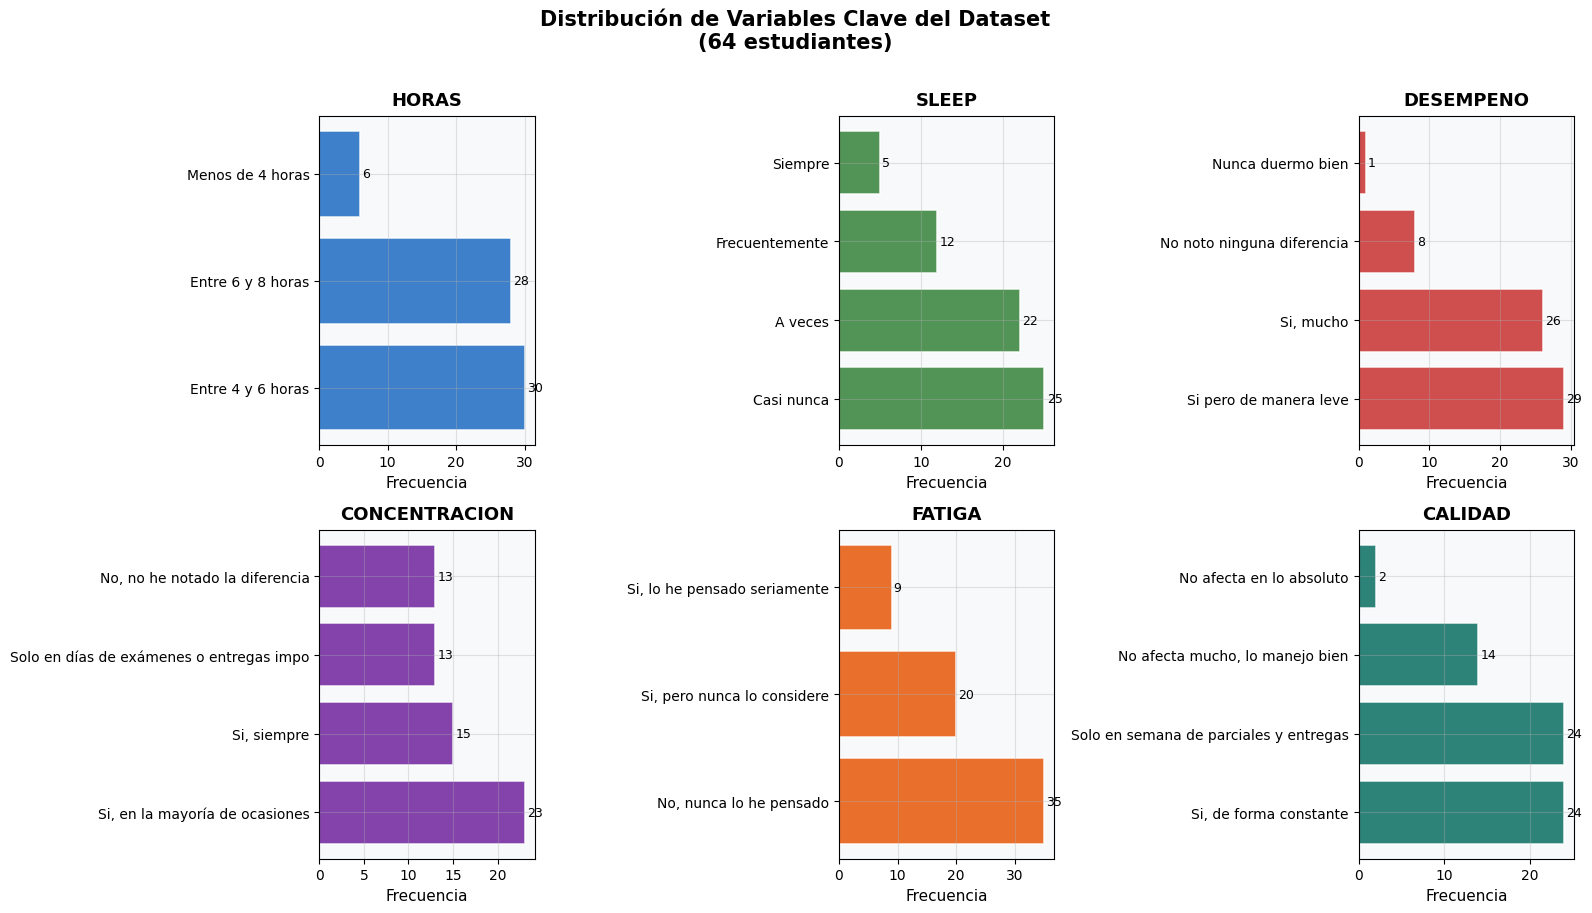

In [107]:
# ─── Distribución de categorías clave ────────────────────────────────────────
variables_clave = ['HORAS', 'SLEEP', 'DESEMPENO', 'CONCENTRACION', 'FATIGA', 'CALIDAD']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

colores = ['#1565C0', '#2E7D32', '#C62828', '#6A1B9A', '#E65100', '#00695C']

for i, (var, color) in enumerate(zip(variables_clave, colores)):
    counts = df_raw[var].value_counts()
    bars = axes[i].barh([str(c)[:40] for c in counts.index], counts.values,
                        color=color, alpha=0.82, edgecolor='white', linewidth=1.2)
    axes[i].set_title(f'{var}', fontweight='bold', pad=8)
    axes[i].set_xlabel('Frecuencia')
    for bar, val in zip(bars, counts.values):
        axes[i].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                     f'{val}', va='center', fontsize=9)

plt.suptitle('Distribución de Variables Clave del Dataset\n(64 estudiantes)', 
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
# 4. Metodología y Bases Teóricas

## 4.1 Preprocesamiento y Limpieza

Antes de aplicar el Análisis de Correspondencia Múltiple (ACM), fue necesario realizar un proceso de depuración, selección y transformación de variables, con el fin de garantizar que la información utilizada fuera consistente con el objetivo del estudio: identificar perfiles educativo-laborales según las condiciones socioeconómicas de la población.

En primer lugar, se excluyeron del análisis las **variables identificadoras**, como `cod_mpio`, `llave`, `hogar`, `orden`, `per005b` y `per006b`, ya que su función es únicamente permitir la trazabilidad de los registros dentro de la base de datos. Aunque son importantes para la organización de la información, no contienen contenido analítico relevante para construir dimensiones factoriales en el ACM.

Posteriormente, se distinguieron las variables según su papel dentro del análisis. Por un lado, se definieron como **variables activas** aquellas que estructuran directamente el espacio factorial, es decir, las que permiten caracterizar los perfiles educativo-laborales. En este grupo se incluyeron variables como `per015`, `per016`, `per017`, `i1`, `i4`, `per019`, `per020`, `i7` e `i8`. Estas variables representan dimensiones asociadas con alfabetización, permanencia educativa, nivel educativo, rezago escolar, actividad laboral, posición ocupacional, desempleo estructural e informalidad.

Por otro lado, variables como `per001`, `per018` y `zona` se incorporaron como **variables ilustrativas**, dado que no participan en la construcción de los ejes principales, pero sí facilitan la interpretación de los perfiles encontrados, por ejemplo, en términos de género, cotización pensional o desigualdad territorial.

Dado que el ACM trabaja con variables categóricas, fue necesario transformar los códigos originales del Sisbén a categorías legibles e interpretables. En este sentido, variables como `per017` (nivel educativo) y `per019` (actividad principal), originalmente registradas mediante códigos numéricos, fueron recodificadas a etiquetas descriptivas. Este proceso no implica convertirlas en variables cuantitativas continuas, sino expresarlas de forma adecuada para el análisis de correspondencias.

En algunos casos, además de la recodificación, fue necesario **agrupar categorías** para mejorar la parsimonia del modelo y evitar una fragmentación excesiva del espacio factorial. Por ejemplo, `per017` fue reorganizada en macro-categorías educativas más amplias, con el propósito de facilitar la interpretación y reducir problemas derivados de categorías con muy baja frecuencia.

Asimismo, los indicadores de privación tipo IPM, como `i1`, `i4`, `i7` e `i8`, fueron tratados como variables categóricas dicotómicas. Aunque en la base aparecen codificados como `0` y `1`, estos valores representan la presencia o ausencia de una condición de privación, por lo que se expresaron en términos sustantivos, como `"Sí"` y `"No"`, para favorecer la lectura de resultados y la interpretación de los planos factoriales.

Un aspecto especialmente importante del preprocesamiento fue el tratamiento de las categorías **“No aplica por flujo”**, presentes en varias variables del Sisbén bajo códigos como `9` o `99`. Estas categorías no describen una característica real del individuo, sino que responden a la lógica interna del cuestionario. Por tanto, su inclusión directa puede introducir distorsiones en el análisis, al generar asociaciones artificiales. Según el caso, estas categorías debieron excluirse, reagruparse o tratarse separadamente, dependiendo de su sentido sustantivo y de su peso en la distribución de frecuencias.

Finalmente, se tuvo en cuenta que el **factor de expansión (`fex`)** no forma parte de las variables analíticas del ACM. Su función no es describir condiciones individuales, sino permitir que cada observación represente un número determinado de personas en la población. Por ello, no se incorpora como variable activa ni ilustrativa, aunque puede utilizarse posteriormente como ponderación para mejorar la representatividad de los resultados.

En conjunto, este proceso de preprocesamiento permitió construir una base coherente con los supuestos del ACM, diferenciando con claridad entre variables estructurales, variables de apoyo interpretativo y variables que debían excluirse del modelo por su naturaleza técnica o identificadora.

---

## Preguntas Guía — Sección 4.1

> 1. ¿Por qué es necesario excluir las variables identificadoras del ACM?  
> 2. ¿Cuál es la diferencia entre variables activas e ilustrativas dentro del análisis?  
> 3. ¿Por qué los códigos originales del Sisbén deben recodificarse a categorías interpretables?  
> 4. ¿Qué ventajas tiene reagrupar categorías, como en el caso del nivel educativo (`per017`)?  
> 5. ¿Qué problemas puede generar incluir categorías como “No aplica por flujo” sin un tratamiento previo?  
> 6. ¿Por qué el factor de expansión (`fex`) no se incorpora como variable dentro del ACM?

In [108]:
# ─── 3.1 Preprocesamiento ────────────────────────────────────────────────────

# Selección de variables categóricas relevantes para el ACM
variables_acm = [
    'HORAS', 
    'SLEEP', 
    # 'CONCENTRACION', 
    # 'DESEMPENO',
    # 'PUNTUALIDAD', 
    # 'FATIGA',
    # 'CALIDAD', 
    # 'GENERO',
    # 'DOBLECARRERA', 
    # 'BECA', 
    'RETIRO'
]

df = df_raw[variables_acm].copy()

# Seleccionar solo las variables activas para el MCA
data_activas = df[variables_acm].copy()

# Estandarización

# data_activas['CONCENTRACION'] = data_activas['CONCENTRACION'].replace({
#     'Si, siempre': 'Siempre',
#     'Si, en la mayoría de ocasiones': 'Mayoría ocasiones', 
#     'Solo en días de exámenes o entregas importantes': 'Solo exámenes',
#     'No, no he notado la diferencia': 'No nota diferencia'
# })

# data_activas['DESEMPENO'] = data_activas['DESEMPENO'].replace({
#     'Si, mucho': 'Mucho',
#     'Si pero de manera leve': 'Leve',
#     'No noto ninguna diferencia': 'No',
#     'Nunca duermo bien': 'No'
# })

# Verificar valores faltantes
print("=== Valores faltantes por variable ===")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "✅ Sin valores faltantes")

print(f"\n📊 Dataset para ACM: {df.shape[0]} filas × {df.shape[1]} variables")
print(f"📁 Número total de categorías: {sum(df[c].nunique() for c in df.columns)}")

=== Valores faltantes por variable ===
✅ Sin valores faltantes

📊 Dataset para ACM: 64 filas × 3 variables
📁 Número total de categorías: 9


## 4.2 Construcción de Matrices

### Matriz Indicadora $Z$

Mediante **one-hot encoding** se construye $Z$ de dimensión $n \times J$ donde $J$ es el total de categorías:

$$Z = [Z_1 | Z_2 | \cdots | Z_Q]$$

### Matriz de Burt $B = Z^T Z$

Matriz simétrica que recoge todas las **tabulaciones cruzadas** entre variables. En la diagonal: frecuencias de cada categoría. Fuera: co-ocurrencias.

### Matriz de Residuos Estandarizados

$$S = D_r^{-1/2}\,(P - r c^T)\,D_c^{-1/2}$$

- $r_{ij} > +2$: **atracción** significativa entre categorías $i$ y $j$
- $r_{ij} < -2$: **repulsión** significativa


# Preguntas Guía — Sección 4.2

## 1. ¿Qué representa la Matriz de Burt?

La **Matriz de Burt** es una matriz simétrica que contiene todas las **tabulaciones cruzadas entre las categorías de las variables** incluidas en el análisis.

Se define como:

$$
B = Z^T Z
$$

donde:

- $Z$ es la matriz indicadora (one-hot encoding)  
- $B$ tiene dimensión $J \times J$, siendo $J$ el total de categorías  

### Interpretación:

- 🔹 **Diagonal**: frecuencia de cada categoría  
- 🔹 **Fuera de la diagonal**: número de veces que dos categorías aparecen juntas (co-ocurrencias)  

En otras palabras: la matriz de Burt resume **cómo se relacionan todas las categorías entre sí** en un solo objeto.


## 2. ¿Qué son los residuos estandarizados y qué indican?

Los **residuos estandarizados** miden la diferencia entre:

- lo que **realmente ocurre (observado)**  
- y lo que **se esperaría si no hubiera relación entre variables (esperado)**  

Se calculan como:

$$
S = D_r^{-1/2}\,(P - r c^T)\,D_c^{-1/2}
$$

### Interpretación:

- $S_{ij} > +2$ → **Asociación positiva fuerte (atracción)**  
- $S_{ij} < -2$ → **Asociación negativa (repulsión)**  
- $S_{ij} \approx 0$ → **Independencia**  

Indican qué combinaciones de categorías son **más frecuentes o menos frecuentes de lo esperado**.



## 3. ¿Qué significa comparar valores observados con valores esperados?

Significa evaluar si dos categorías están relacionadas o no.

- 🔹 **Valor observado ($O_{ij}$)**: cuántas veces aparecen juntas en los datos  
- 🔹 **Valor esperado ($E_{ij}$)**: cuántas veces deberían aparecer juntas **si fueran independientes**  

$$
E_{ij} = r_i \cdot c_j
$$

Entonces:

- Si $O_{ij} > E_{ij}$ → hay más relación de la esperada  
- Si $O_{ij} < E_{ij}$ → hay menos relación de la esperada  

## 4. ¿Qué indica un residuo positivo o negativo?

- **Residuo positivo ($>0$)**  
  → Las categorías aparecen juntas **más de lo esperado**  
  → Existe **asociación o afinidad**  

- **Residuo negativo ($<0$)**  
  → Las categorías aparecen juntas **menos de lo esperado**  
  → Existe **rechazo o disociación**  


##  Resumen
La matriz de Burt permite sintetizar las relaciones entre todas las categorías del conjunto de variables, mientras que los residuos estandarizados permiten identificar asociaciones significativas entre ellas, comparando las frecuencias observadas con aquellas esperadas bajo independencia.

Estas matrices constituyen la base del Análisis de Correspondencia Múltiple, ya que permiten transformar las relaciones categóricas en una estructura algebraica que posteriormente es descompuesta mediante técnicas espectrales para obtener las dimensiones factoriales.

In [109]:
# ─── Construcción de la Matriz Disyuntiva Completa (Indicator Matrix) ────────

# Codificación one-hot: cada categoría se convierte en columna binaria
Z = pd.get_dummies(df, columns=variables_acm, dtype=int)

print(f"Dimensiones de la Matriz Indicadora Z: {Z.shape}")
print(f"  → {Z.shape[0]} individuos (estudiantes)")
print(f"  → {Z.shape[1]} columnas (categorías codificadas)")
print("\nPrimeras 5 filas, primeras 10 columnas:")
Z.iloc[:5, :10]

Dimensiones de la Matriz Indicadora Z: (64, 9)
  → 64 individuos (estudiantes)
  → 9 columnas (categorías codificadas)

Primeras 5 filas, primeras 10 columnas:


,HORAS_Entre 4 y 6 horas,HORAS_Entre 6 y 8 horas,HORAS_Menos de 4 horas,SLEEP_A veces,SLEEP_Casi nunca,SLEEP_Frecuentemente,SLEEP_Siempre,RETIRO_No,RETIRO_Si
0,1,0,0,0,0,1,0,1,0
1,0,1,0,0,1,0,0,1,0
2,0,1,0,1,0,0,0,1,0
3,1,0,0,1,0,0,0,1,0
4,0,1,0,0,1,0,0,1,0


Dimensiones de la Matriz de Burt B: (9, 9)

Es simétrica: True
Suma de la diagonal (total de respuestas): 192


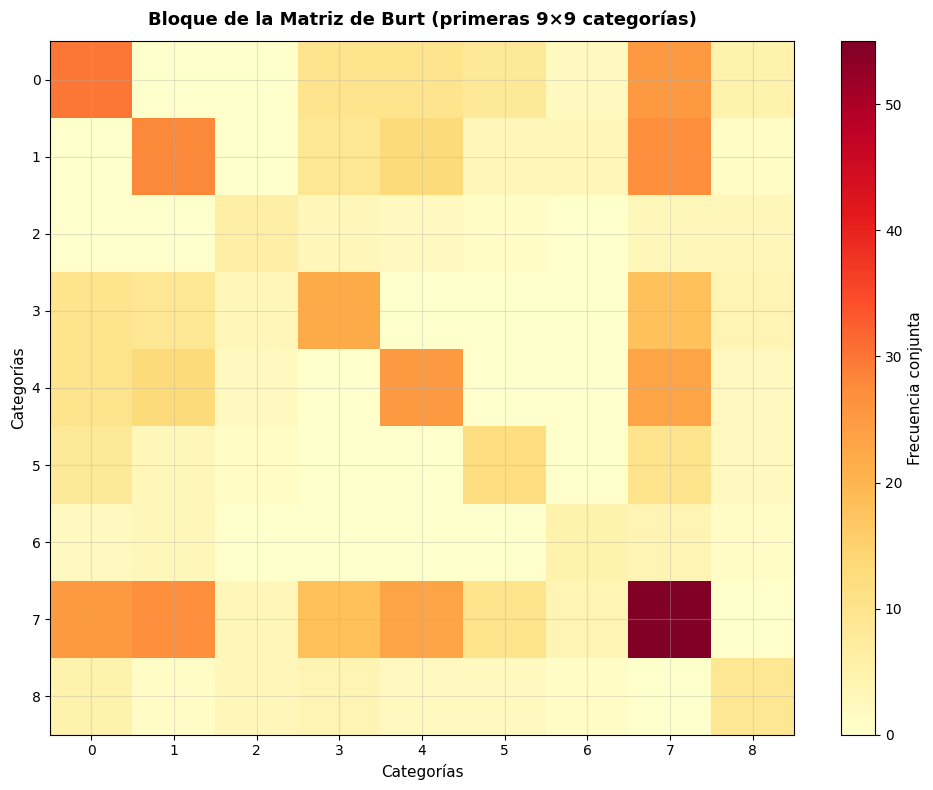

In [110]:
# ─── 3.2 Construcción de la Matriz de Burt ───────────────────────────────────

Z_array = Z.values.astype(float)
B = Z_array.T @ Z_array  # Matriz de Burt: B = Z^T * Z

print(f"Dimensiones de la Matriz de Burt B: {B.shape}")
print(f"\nEs simétrica: {np.allclose(B, B.T)}")
print(f"Suma de la diagonal (total de respuestas): {np.trace(B):.0f}")

# Visualización de un bloque de la Matriz de Burt
fig, ax = plt.subplots(figsize=(10, 8))
block_size = min(20, B.shape[0])
im = ax.imshow(B[:block_size, :block_size], cmap='YlOrRd', aspect='auto')
ax.set_title(f'Bloque de la Matriz de Burt (primeras {block_size}×{block_size} categorías)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Categorías')
ax.set_ylabel('Categorías')
plt.colorbar(im, ax=ax, label='Frecuencia conjunta')
plt.tight_layout()
plt.show()

In [111]:
# ─── Construcción de la Matriz de Residuos Estandarizados ────────────────────

n = Z_array.shape[0]   # número de individuos
Q = len(variables_acm) # número de variables

# Matriz de proporciones P = Z / (n * Q)
P = Z_array / (n * Q)

# Masas de filas y columnas
r = P.sum(axis=1)  # masas de filas
c = P.sum(axis=0)  # masas de columnas

# Matrices de ponderación diagonal
Dr_inv_sqrt = np.diag(1.0 / np.sqrt(r))
Dc_inv_sqrt = np.diag(1.0 / np.sqrt(c + 1e-12))

# Matriz de residuos estandarizados
S = Dr_inv_sqrt @ (P - np.outer(r, c)) @ Dc_inv_sqrt

print(f"Dimensiones de la Matriz de Residuos S: {S.shape}")
print(f"Rango de valores: [{S.min():.4f}, {S.max():.4f}]")
print(f"Número de residuos |S| > 2 (asociaciones significativas): {(np.abs(S) > 2).sum()}")

Dimensiones de la Matriz de Residuos S: (64, 9)
Rango de valores: [-0.0669, 0.2380]
Número de residuos |S| > 2 (asociaciones significativas): 0


### Interpretación de la matriz de Burt

La matriz de Burt permite observar la frecuencia conjunta entre categorías de las variables analizadas. Los elementos diagonales corresponden a las frecuencias marginales, mientras que los elementos fuera de la diagonal representan co-ocurrencias entre categorías.

Asimismo, se evidencian patrones relevantes como la presencia de individuos con educación primaria que no saben leer y escribir, lo cual sugiere rezagos en la calidad educativa.

Por otro lado, se detecta un grupo de observaciones con categorías "No aplica" que presentan coincidencias exactas entre variables, lo cual indica posibles dependencias entre estas y no seria una relacion real entre categorias.

## 4.3 Descomposición en Valores Singulares (DVS)

El núcleo matemático del Análisis de Correspondencia Múltiple (ACM) es la **Descomposición en Valores Singulares (DVS)** aplicada a la matriz de residuos estandarizados:

$$
S = U \cdot D \cdot V^T
$$

Esta descomposición permite representar la estructura de relaciones entre categorías e individuos en un espacio de menor dimensión, conservando la mayor parte de la información relevante.

---

### Interpretación de las matrices

| Matriz | Dimensión | Interpretación |
|--------|----------|----------------|
| $U$ | $n \times k$ | Coordenadas de los **individuos** en el espacio factorial |
| $D$ | $k \times k$ | Matriz diagonal con los **valores singulares** $\mu_k$ |
| $V$ | $J \times k$ | Coordenadas de las **categorías** en el espacio factorial |

---

###Valores singulares y autovalores

Los valores singulares $\mu_k$ permiten obtener los **autovalores**:

$$
\lambda_k = \mu_k^2
$$

Estos autovalores representan la **inercia explicada** por cada dimensión, es decir, la proporción de variabilidad capturada por cada eje factorial.

---

### Interpretación en el contexto del ACM

- Cada dimensión (factor) resume un patrón de asociación entre categorías.
- Las primeras dimensiones concentran la mayor parte de la información.
- La proyección en pocas dimensiones permite visualizar relaciones complejas de forma simple.

En otras palabras, la DVS transforma un problema de alta dimensión en un espacio reducido donde las relaciones entre categorías son interpretables.

---

## Preguntas Guía — Sección 4.3

### 1. ¿Qué es la DVS?

La Descomposición en Valores Singulares (DVS) es una técnica algebraica que factoriza una matriz en tres componentes, permitiendo identificar las direcciones principales de variación en los datos.

---

### 2. ¿Qué representan las matrices $U$, $D$ y $V$?

- $U$: representa la posición de los individuos en el espacio reducido  
- $D$: contiene la magnitud de la variabilidad (valores singulares)  
- $V$: representa la posición de las categorías en el espacio factorial  

---

### 3. ¿Por qué la DVS permite reducir la dimensionalidad?

Porque ordena las dimensiones según su importancia (inercia).  
Las primeras dimensiones concentran la mayor parte de la información, lo que permite trabajar con menos variables sin perder capacidad explicativa.

---

### 4. ¿Qué relación existe entre valores singulares y autovalores?

Los autovalores se obtienen como el cuadrado de los valores singulares:

$$
\lambda_k = \mu_k^2
$$

Estos cuantifican la cantidad de inercia explicada por cada dimensión, siendo fundamentales para decidir cuántas dimensiones conservar en el análisis.

---

## Nota

La DVS constituye el paso fundamental del ACM, ya que permite identificar las dimensiones latentes que estructuran las relaciones entre categorías, facilitando su representación e interpretación en un espacio de baja dimensión.

In [112]:
# ─── 3.3 Descomposición en Valores Singulares (DVS) ──────────────────────────

U, singular_values, Vt = np.linalg.svd(S, full_matrices=False)
V = Vt.T

# Autovalores (inercia por dimensión)
eigenvalues = singular_values ** 2

print("=" * 55)
print(" DVS — Resultados")
print("=" * 55)
print(f"\nMatriz U (individuos): {U.shape}")
print(f"Valores singulares D:  {singular_values.shape}")
print(f"Matriz V (categorías): {V.shape}")

print(f"\n{'Dim':>4} {'Val. Singular (μ)':>20} {'Autovalor (λ=μ²)':>20} {'Inercia %':>12}")
print("-" * 60)
total_inercia = eigenvalues.sum()
for k in range(min(10, len(eigenvalues))):
    pct = 100 * eigenvalues[k] / total_inercia
    print(f"{k+1:>4} {singular_values[k]:>20.6f} {eigenvalues[k]:>20.6f} {pct:>11.2f}%")

 DVS — Resultados

Matriz U (individuos): (64, 9)
Valores singulares D:  (9,)
Matriz V (categorías): (9, 9)

 Dim    Val. Singular (μ)     Autovalor (λ=μ²)    Inercia %
------------------------------------------------------------
   1             0.697258             0.486168       24.31%
   2             0.623884             0.389231       19.46%
   3             0.586728             0.344250       17.21%
   4             0.561488             0.315269       15.76%
   5             0.518876             0.269232       13.46%
   6             0.442549             0.195850        9.79%
   7             0.000000             0.000000        0.00%
   8             0.000000             0.000000        0.00%
   9             0.000000             0.000000        0.00%


## Criterio de Kaiser
El criterio de Kaiser es una regla para decidir cuántas dimensiones (factores) conservar en un análisis como PCA o ACM.

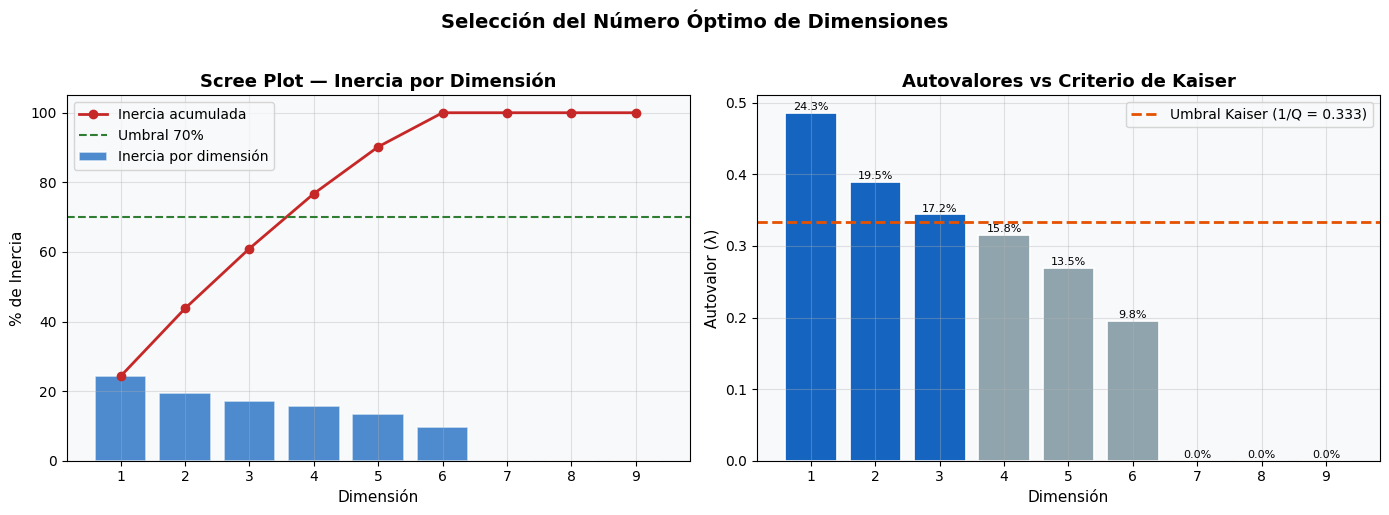


📌 Dimensiones con λ > 1/Q (0.333): 3
📌 Dimensiones para ≥ 70% de inercia: 4
📌 Inercia de Dim 1: 24.31%
📌 Inercia de Dim 2: 19.46%
📌 Inercia acumulada Dim 1+2: 43.77%


In [113]:
# ─── 3.4 Inercia y Selección de Dimensiones ──────────────────────────────────

inercia_pct = 100 * eigenvalues / eigenvalues.sum()
inercia_acum = np.cumsum(inercia_pct)
umbral_kaiser = 1 / len(variables_acm)

# ── Scree Plot ────────────────────────────────────────────────────────────────
n_dims = min(15, len(eigenvalues))
dims = np.arange(1, n_dims + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Scree Plot
ax1.bar(dims, inercia_pct[:n_dims], color='#1565C0', alpha=0.75,
        edgecolor='white', linewidth=1.2, label='Inercia por dimensión')
ax1.plot(dims, inercia_acum[:n_dims], 'o-', color='#C62828', linewidth=2,
         markersize=6, label='Inercia acumulada')
ax1.axhline(y=70, color='#2E7D32', linestyle='--', linewidth=1.5,
            label='Umbral 70%')
ax1.set_xlabel('Dimensión')
ax1.set_ylabel('% de Inercia')
ax1.set_title('Scree Plot — Inercia por Dimensión', fontweight='bold')
ax1.set_xticks(dims)
ax1.legend()

# Autovalores vs Umbral Kaiser
colores_bar = ['#1565C0' if ev > umbral_kaiser else '#90A4AE' for ev in eigenvalues[:n_dims]]
ax2.bar(dims, eigenvalues[:n_dims], color=colores_bar, edgecolor='white', linewidth=1.2)
ax2.axhline(y=umbral_kaiser, color='#E65100', linestyle='--', linewidth=2,
            label=f'Umbral Kaiser (1/Q = {umbral_kaiser:.3f})')
ax2.set_xlabel('Dimensión')
ax2.set_ylabel('Autovalor (λ)')
ax2.set_title('Autovalores vs Criterio de Kaiser', fontweight='bold')
ax2.set_xticks(dims)
ax2.legend()

# Anotaciones
for i, (ev, pct) in enumerate(zip(eigenvalues[:n_dims], inercia_pct[:n_dims])):
    ax2.text(i+1, ev + 0.001, f'{pct:.1f}%', ha='center', va='bottom', fontsize=8)

plt.suptitle('Selección del Número Óptimo de Dimensiones', fontsize=14,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Determinar número de dimensiones a retener
n_ret = np.argmax(inercia_acum >= 70) + 1
print(f"\n📌 Dimensiones con λ > 1/Q ({umbral_kaiser:.3f}): {(eigenvalues > umbral_kaiser).sum()}")
print(f"📌 Dimensiones para ≥ 70% de inercia: {n_ret}")
print(f"📌 Inercia de Dim 1: {inercia_pct[0]:.2f}%")
print(f"📌 Inercia de Dim 2: {inercia_pct[1]:.2f}%")
print(f"📌 Inercia acumulada Dim 1+2: {inercia_acum[1]:.2f}%")

---
## 4.5 Visualización e Interpretación: Biplot

| Observación geométrica | Interpretación |
|------------------------|----------------|
| Dos categorías **muy cercanas** | Tienden a aparecer en los mismos individuos |
| Categorías en **extremos opuestos** | Definen el contraste del eje |
| Punto **cerca del origen** | Comportamiento promedio, sin rasgo distintivo |
| Punto **lejos del origen** | Perfil muy atípico |

### Principio del centroide
- Individuo = promedio ponderado de sus categorías.
- Categoría = promedio ponderado de los individuos que la responden.

---

## 🔑 Preguntas Guía — Sección 4.5

> 1. ¿Cómo se interpretan las distancias entre puntos en el plano factorial?
> 2. ¿Qué significa que dos categorías estén cerca?
> 3. ¿Qué representa el origen?
> 4. ¿Qué es un biplot y qué información proporciona?
> 5. ¿Qué significa la polaridad de un eje?
> 6. ¿Qué indica que un punto esté lejos del origen?

In [114]:
# ─── Cálculo de Coordenadas Principales ──────────────────────────────────────

# Coordenadas principales de individuos: Φ = Dr^{-1/2} * U * D
coord_individuos = Dr_inv_sqrt @ U * singular_values

# Coordenadas principales de categorías: Γ = Dc^{-1/2} * V * D
coord_categorias = Dc_inv_sqrt @ V * singular_values

# Crear DataFrame de coordenadas de categorías con nombres
nombres_cat = Z.columns.tolist()
df_cat_coords = pd.DataFrame({
    'Categoría': nombres_cat,
    'Dim1': coord_categorias[:, 0],
    'Dim2': coord_categorias[:, 1]
})

# Extraer variable de origen de cada categoría
df_cat_coords['Variable'] = df_cat_coords['Categoría'].apply(
    lambda x: '_'.join(x.split('_')[:-1]) if '_' in x else x
)

print("Coordenadas principales de las primeras categorías:")
df_cat_coords.head(10)

Coordenadas principales de las primeras categorías:


,Categoría,Dim1,Dim2,Variable
0,HORAS_Entre 4 y 6 horas,-0.277965,-0.776994,HORAS
1,HORAS_Entre 6 y 8 horas,0.724785,0.517600,HORAS
2,HORAS_Menos de 4 horas,-1.992504,1.469503,HORAS
3,SLEEP_A veces,-0.420337,0.468338,SLEEP
4,SLEEP_Casi nunca,0.524506,0.280828,SLEEP
5,SLEEP_Frecuentemente,-0.496824,-1.513224,SLEEP
6,SLEEP_Siempre,0.419331,0.166913,SLEEP
7,RETIRO_No,0.311257,-0.066855,RETIRO
8,RETIRO_Si,-1.902127,0.408557,RETIRO


In [115]:
# ─── ACM con la librería Prince (implementación estándar) ────────────────────
# Prince implementa el ACM según el estándar de Greenacre (2017)
import prince

mca = prince.MCA(
    n_components=8,
    n_iter=10,
    random_state=42
)
mca = mca.fit(df)

print("=" * 50)
print(" ACM — Biblioteca Prince")
print("=" * 50)
print(f"\nVarianza explicada por dimensión:")
ev = mca.eigenvalues_
total = ev.sum()
for k, val in enumerate(ev):
    print(f"  Dim {k+1}: λ = {val:.4f}  ({100*val/total:.2f}%)")
print(f"  Acumulado Dim 1+2: {100*(ev[0]+ev[1])/total:.2f}%")

 ACM — Biblioteca Prince

Varianza explicada por dimensión:
  Dim 1: λ = 0.4862  (24.31%)
  Dim 2: λ = 0.3892  (19.46%)
  Dim 3: λ = 0.3443  (17.21%)
  Dim 4: λ = 0.3153  (15.76%)
  Dim 5: λ = 0.2692  (13.46%)
  Dim 6: λ = 0.1958  (9.79%)
  Dim 7: λ = 0.0000  (0.00%)
  Dim 8: λ = 0.0000  (0.00%)
  Acumulado Dim 1+2: 43.77%


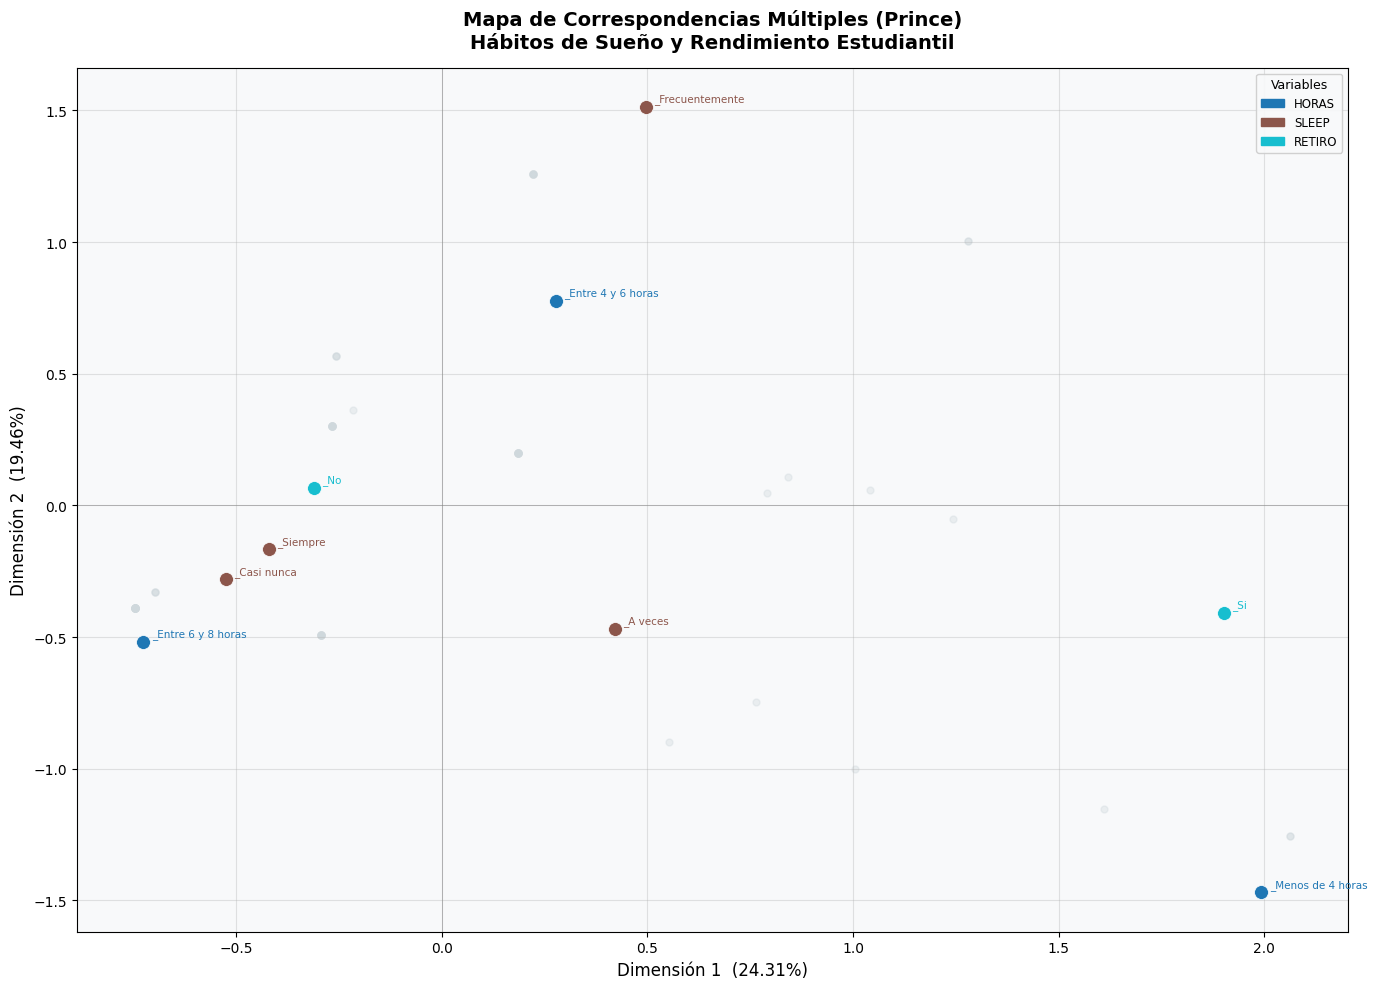

In [116]:
# ─── Mapa Factorial con Prince ───────────────────────────────────────────────

# Coordenadas de categorías (Prince)
cat_coords = mca.column_coordinates(df)
ind_coords = mca.row_coordinates(df)

inercia_prince = 100 * mca.eigenvalues_ / mca.eigenvalues_.sum()

fig, ax = plt.subplots(figsize=(14, 10))

ax.axhline(0, color='gray', linewidth=0.7, linestyle='-', alpha=0.5)
ax.axvline(0, color='gray', linewidth=0.7, linestyle='-', alpha=0.5)

# Individuos
ax.scatter(ind_coords.iloc[:, 0], ind_coords.iloc[:, 1],
           color='#CFD8DC', alpha=0.35, s=25, zorder=1, label='Individuos')

# Determinar variable de origen para cada categoría
cat_vars = []
for col in cat_coords.index:
    for v in variables_acm:
        if col.startswith(v + '_'):
            cat_vars.append(v)
            break
    else:
        cat_vars.append('Otro')

cat_coords['Variable'] = cat_vars
palette2 = plt.cm.get_cmap('tab10', len(variables_acm))
color_map2 = {v: palette2(i) for i, v in enumerate(variables_acm)}

for var in variables_acm:
    sub = cat_coords[cat_coords['Variable'] == var]
    color = color_map2[var]
    ax.scatter(sub.iloc[:, 0], sub.iloc[:, 1],
               color=color, s=100, zorder=4, edgecolors='white', linewidths=0.5)
    for idx, row in sub.iterrows():
        label = str(idx).replace(var + '_', '')[:25]
        ax.annotate(label,
                    xy=(row.iloc[0], row.iloc[1]),
                    xytext=(6, 4), textcoords='offset points',
                    fontsize=7.5, color=color)

handles2 = [mpatches.Patch(color=color_map2[v], label=v) for v in variables_acm]
ax.legend(handles=handles2, loc='upper right', fontsize=8.5, framealpha=0.9,
          title='Variables', title_fontsize=9)

ax.set_xlabel(f'Dimensión 1  ({inercia_prince[0]:.2f}%)', fontsize=12)
ax.set_ylabel(f'Dimensión 2  ({inercia_prince[1]:.2f}%)', fontsize=12)
ax.set_title('Mapa de Correspondencias Múltiples (Prince)\n'
             'Hábitos de Sueño y Rendimiento Estudiantil',
             fontsize=14, fontweight='bold', pad=14)

plt.tight_layout()
plt.show()

# 5. Interpretación de los ejes factoriales

Este análisis incluye tres variables: `HORAS` (cantidad promedio
de horas de sueño), `SLEEP` (frecuencia de sueño adecuado) y `RETIRO`
(si el estudiante ha retirado asignaturas). Con un umbral de Kaiser de
1/Q = 0.333, solo las tres primeras dimensiones lo superan, lo que
indica que las estructuras que explican la mayor variabilidad entre estas variables se
concentra principalmente en estas dimensiones.

---

## Dimensión 1 (24.31% de inercia): Retiro académico asociado al déficit de sueño

Esta dimensión es la más informativa del análisis. Según la contribución
por variable, es estructurada principalmente por `RETIRO` (1.857) y
`HORAS` (1.524), con `SLEEP` en un papel secundario (0.219).

**Polo positivo (+):**
- `RETIRO_Sí` (+1.90): estudiantes que han retirado al menos una
  asignatura
- `HORAS_Menos de 4 horas` (+1.99): estudiantes con déficit severo
  de sueño
- `SLEEP_A veces` y `SLEEP_Frecuentemente`: frecuencia de sueño
  adecuado irregular o intermitente

**Polo negativo (−):**
- `RETIRO_No` (−0.31): estudiantes sin retiros
- `HORAS_Entre 6 y 8 horas` (−0.72): duración de sueño dentro del
  rango recomendado
- `SLEEP_Siempre` y `SLEEP_Casi nunca`: categorías de frecuencia
  extremas

**Interpretación:**
Este eje revela que el retiro de asignaturas y el sueño menor a 4
horas coexisten de forma sistemática en los mismos estudiantes. La
proximidad de `RETIRO_Sí` y `Menos de 4 horas` en el polo positivo,
con una distancia combinada que los ubica como las categorías más
extremas del eje, sugiere que el déficit severo de sueño es la
condición que más consistentemente se asocia a la deserción parcial
académica en esta muestra.

Resulta notable que `SLEEP_Siempre` y `SLEEP_Casi nunca` compartan
el mismo polo con `RETIRO_No`. Esto indica que la frecuencia de sueño
adecuado por sí sola no discrimina el retiro tanto como la cantidad
de horas: tanto estudiantes con sueño siempre adecuado como aquellos
que casi nunca lo tienen pueden no haber retirado materias, siempre
que sus horas de sueño estén en el rango de 6 a 8 horas.

---

## Dimensión 2 (19.46% de inercia): Cantidad vs calidad del sueño

La segunda dimensión reorganiza el espacio según las variables de
sueño, con `HORAS` como variable dominante (1.010) y `SLEEP` en
segundo lugar (0.654). `RETIRO` contribuye marginalmente (0.086),
lo que indica que esta dimensión captura variación en los patrones
de sueño independientemente del retiro académico.

**Polo positivo (+):**
- `SLEEP_Frecuentemente` (+1.51): frecuencia de sueño adecuado alta
- `HORAS_Entre 4 y 6 horas` (+0.78): sueño breve pero con cierta
  regularidad en su calidad

**Polo negativo (−):**
- `HORAS_Menos de 4 horas` (−1.47): déficit severo de cantidad
- `HORAS_Entre 6 y 8 horas` (−0.52): sueño en rango óptimo
- `SLEEP_A veces` (−0.47): calidad irregular
- `RETIRO_Sí` (−0.41): refuerzo del retiro en este polo

**Interpretación:**
Este eje introduce un contraste dentro de los estudiantes con escasas
horas de sueño: aquellos que duermen entre 4 y 6 horas pero perciben
su sueño como frecuentemente adecuado se separan de quienes duermen
menos de 4 horas con calidad muy irregular. La segunda dimensión
diferencia por tanto entre un déficit cuantitativo compensado
subjetivamente (polo +) y un déficit cuantitativo severo sin
compensación de calidad (polo −).

In [117]:
# ─── 4. Análisis de Dimensiones ──────────────────────────────────────────────

# Identificar las categorías que más contribuyen a cada dimensión
cat_coords_num = cat_coords.iloc[:, :2].copy()
cat_coords_num.columns = ['Dim1', 'Dim2']
cat_coords_num['Variable'] = cat_vars

print("=" * 60)
print(" Top 8 categorías más extremas — DIMENSIÓN 1")
print("=" * 60)
top_dim1 = cat_coords_num.nlargest(4, 'Dim1')[['Dim1', 'Variable']]
bot_dim1 = cat_coords_num.nsmallest(4, 'Dim1')[['Dim1', 'Variable']]
print("\nPolo POSITIVO (+):")
print(top_dim1.to_string())
print("\nPolo NEGATIVO (−):")
print(bot_dim1.to_string())

print("\n" + "=" * 60)
print(" Top 8 categorías más extremas — DIMENSIÓN 2")
print("=" * 60)
top_dim2 = cat_coords_num.nlargest(4, 'Dim2')[['Dim2', 'Variable']]
bot_dim2 = cat_coords_num.nsmallest(4, 'Dim2')[['Dim2', 'Variable']]
print("\nPolo POSITIVO (+):")
print(top_dim2.to_string())
print("\nPolo NEGATIVO (−):")
print(bot_dim2.to_string())

 Top 8 categorías más extremas — DIMENSIÓN 1

Polo POSITIVO (+):
                             Dim1 Variable
HORAS__Menos de 4 horas  1.992504    HORAS
RETIRO__Si               1.902127   RETIRO
SLEEP__Frecuentemente    0.496824    SLEEP
SLEEP__A veces           0.420337    SLEEP

Polo NEGATIVO (−):
                              Dim1 Variable
HORAS__Entre 6 y 8 horas -0.724785    HORAS
SLEEP__Casi nunca        -0.524506    SLEEP
SLEEP__Siempre           -0.419331    SLEEP
RETIRO__No               -0.311257   RETIRO

 Top 8 categorías más extremas — DIMENSIÓN 2

Polo POSITIVO (+):
                              Dim2 Variable
SLEEP__Frecuentemente     1.513224    SLEEP
HORAS__Entre 4 y 6 horas  0.776994    HORAS
RETIRO__No                0.066855   RETIRO
SLEEP__Siempre           -0.166913    SLEEP

Polo NEGATIVO (−):
                              Dim2 Variable
HORAS__Menos de 4 horas  -1.469503    HORAS
HORAS__Entre 6 y 8 horas -0.517600    HORAS
SLEEP__A veces           -0.468338    SLEE

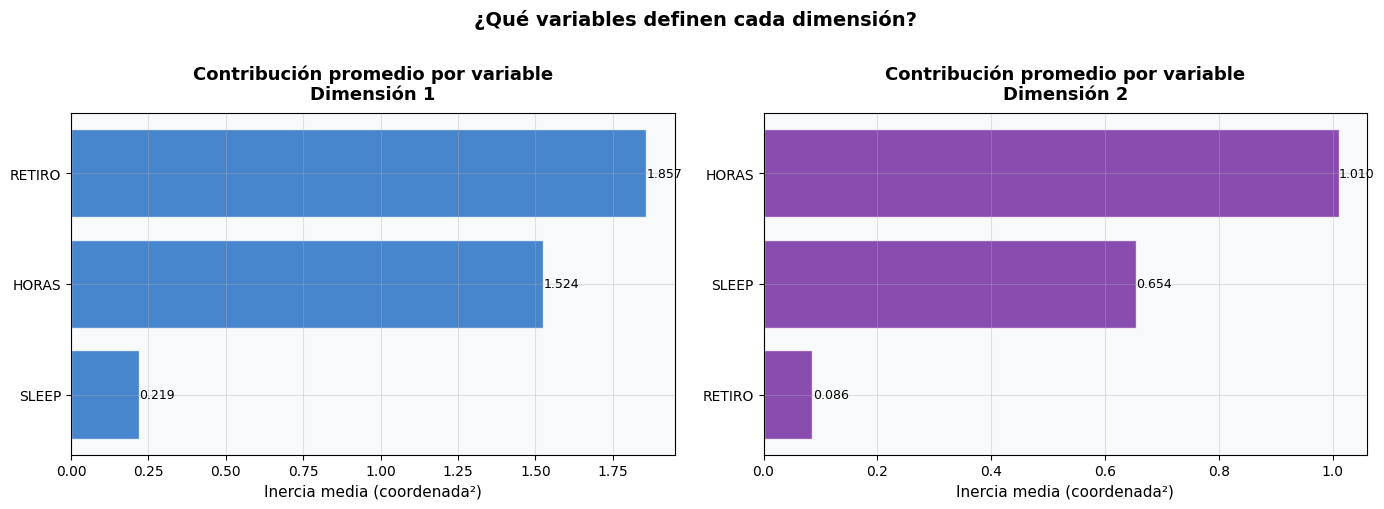

In [118]:
# ─── Contribución de variables por dimensión ─────────────────────────────────

contrib_dim1 = cat_coords_num.groupby('Variable')['Dim1'].apply(lambda x: (x**2).mean())
contrib_dim2 = cat_coords_num.groupby('Variable')['Dim2'].apply(lambda x: (x**2).mean())

df_contrib = pd.DataFrame({'Dimensión 1': contrib_dim1, 'Dimensión 2': contrib_dim2})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, (dim, color) in enumerate([('Dimensión 1', '#1565C0'), ('Dimensión 2', '#6A1B9A')]):
    vals = df_contrib[dim].sort_values(ascending=True)
    bars = axes[i].barh(vals.index, vals.values, color=color, alpha=0.78,
                        edgecolor='white', linewidth=1)
    axes[i].set_title(f'Contribución promedio por variable\n{dim}',
                      fontweight='bold', pad=10)
    axes[i].set_xlabel('Inercia media (coordenada²)')
    for bar, val in zip(bars, vals.values):
        axes[i].text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                     f'{val:.3f}', va='center', fontsize=9)

plt.suptitle('¿Qué variables definen cada dimensión?', fontsize=14,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [119]:
# ─── Resumen estadístico de resultados ───────────────────────────────────────

print("" + "="*60)
print(" RESUMEN DE RESULTADOS DEL ACM")
print("="*60)
print(f"\n🔢 Muestra: {df.shape[0]} estudiantes")
print(f"📋 Variables analizadas: {len(variables_acm)}")
print(f"🏷️  Total de categorías: {Z.shape[1]}")
print(f"\n📊 Inercia total (ACM): {mca.eigenvalues_.sum():.4f}")
print(f"\n  Dimensión 1: λ={mca.eigenvalues_[0]:.4f} | {inercia_prince[0]:.2f}% de la inercia")
print(f"  Dimensión 2: λ={mca.eigenvalues_[1]:.4f} | {inercia_prince[1]:.2f}% de la inercia")
print(f"  Acumulado:   {inercia_prince[0]+inercia_prince[1]:.2f}%")
print(f"\n✅ El plano factorial Dim1–Dim2 resume el ")
print(f"   {inercia_prince[0]+inercia_prince[1]:.1f}% de la información total del dataset.")

 RESUMEN DE RESULTADOS DEL ACM

🔢 Muestra: 64 estudiantes
📋 Variables analizadas: 3
🏷️  Total de categorías: 9

📊 Inercia total (ACM): 2.0000

  Dimensión 1: λ=0.4862 | 24.31% de la inercia
  Dimensión 2: λ=0.3892 | 19.46% de la inercia
  Acumulado:   43.77%

✅ El plano factorial Dim1–Dim2 resume el 
   43.8% de la información total del dataset.


# 6. Conclusiones

La Dimensión 1 revela que la principal fuente de diferenciación
entre individuos es la
**participación o no participación en alguna forma de actividad
laboral**. El polo activo agrupa indistintamente a trabajadores
del sector público y a trabajadores por cuenta propia —categoría
predominantemente informal en Colombia— lo que indica que el eje
divisor real en esta población es la vinculación al mercado de
trabajo, no la calidad de esa vinculación.

La Dimensión 2 introduce una distinción más fina: dentro de quienes
tienen actividad declarada, separa las posiciones de mayor autonomía
o institucionalidad frente al trabajo subordinado de baja
calificación. La co-presencia de analfabetismo en el polo negativo
de ambas dimensiones confirma que la exclusión educativa severa
es transversal a las formas más precarias de inserción laboral.

Respecto a las variables ilustrativas, el sexo no estructura de
forma significativa el espacio factorial, lo que sugiere que hombres
y mujeres del Sisbén IV comparten condiciones estructurales similares
de vulnerabilidad. La cotización a pensión sí se desplaza hacia el
polo de mayor participación laboral, confirmando que la formalidad
opera como variable de segundo orden dentro de quienes ya participan
en el mercado. La zona urbano-rural no domina el plano, aunque
el cuadrante de mayor vulnerabilidad (−,−) tiene una composición
levemente más rural.

Finalmente, con 44.7% de inercia acumulada en dos dimensiones y
seis dimensiones por encima del umbral de Kaiser, el plano factorial
captura la estructura principal pero no la totalidad de la
heterogeneidad presente. Esto implica que existen perfiles
intermedios que no quedan completamente representados y que
políticas uniformes para toda la población Sisbén IV pueden
pasar por alto estas diferencias internas.

## Flujo completo del ACM

```
Datos categóricos (n × Q)
        ↓
Matriz Indicadora Z o Matriz Disyuntiva Completa (n × J)
        ↓
Matriz de Burt B = ZᵀZ  (J × J)
        ↓
Matriz de Residuos S = Dr⁻¹/² (P − rcᵀ) Dc⁻¹/²
        ↓
DVS:  S = U D Vᵀ
        ↓
Autovalores λₖ = μₖ²  →  Inercia por dimensión
        ↓
Coordenadas principales (Φ, Γ)
        ↓
Mapa Factorial / Biplot
        ↓
Interpretación de perfiles
```

## Referencias

- Greenacre, M. (2017). *Correspondence Analysis in Practice* (3rd ed.). CRC Press.
- DNP (2022). *Documentación técnica Sisbén IV*. Departamento Nacional de Planeación.
- Datos Abiertos Colombia: https://www.datos.gov.co/Estad-sticas-Nacionales/DNP-Sisb-n-Personas/hq2v-5umk
- Abdi, H. & Valentin, D. (2007). Multiple Correspondence Analysis. *Encyclopedia of Measurement and Statistics*.
- De, F., Sociales, C., De Sociología, D., Fidel, J., & Morales, E. (s/f). UNIVERSIDAD DE CHILE. Uchile.cl. Recuperado el 18 de marzo de 2026, de https://repositorio.uchile.cl/bitstream/handle/2250/113469/cs39-moralesj59.pdf?sequence=1

- Fernández-Avilés y José-María Montero, G. (s/f). Capítulo 35 análisis de correspondencias. Github.Io. Recuperado el 18 de marzo de 2026, de https://cdr-book.github.io/correspondencias.html

- RPubs - Análisis de Correspondencia Múltiple (ACM). (s/f). Rpubs.com. Recuperado el 18 de marzo de 2026, de https://rpubs.com/ocamilocardona/813536

- (S/f-a). Rice.edu. Recuperado el 18 de marzo de 2026, de https://www.stat.rice.edu/~jrojo/PASI/lectures/Costa%20rica/4_Analisis_Correspondencias_Multiples.pdf

- (S/f-b). Fbbva.es. Recuperado el 18 de marzo de 2026, de https://www.fbbva.es/wp-content/uploads/2017/05/dat/DE_2008_practica_analisis_correspondencias.pdf

- (S/f-c). Fuenterrebollo.com. Recuperado el 18 de marzo de 2026, de https://www.fuenterrebollo.com/Economicas/ECONOMETRIA/REDUCIR-DIMENSION/CORRESPONDENCIAS/correspondencias.pdf